# Simplified ASPM Surrogate Modeling Challenge

**Goal:** Build and validate a surrogate model for a simplified artificial-lift setpoint performance modeling problem.

Each row in `simplified_aspm_events.csv` is a historical intervention event: pre-change well state, the setpoint change that was made, and the observed 48-hour liquid-rate response.

Your task is to model the response function:

\[
    f(s, x)
ightarrow \Delta 	ext{liquid rate}
\]

where `s` is the pre-change well state/context and `x` is the setpoint action.

You do **not** need to implement Bayesian optimization or an acquisition function. Focus on:

- data understanding,
- validation design,
- surrogate modeling,
- uncertainty or confidence estimates,
- diagnostics,
- and a safe recommendation rule.

## Expected time

Please spend **no more than 3-5 hours**. We care more about your reasoning and communication than a highly polished production solution.

You are free to use any modeling approach: linear models, trees/boosting, ensembles, Gaussian Processes, Bayesian regression, quantile models, conformal prediction, bootstrapping, or another justified method.

In [1]:
# ===== Imports & global configuration =====
# You may add others as needed.
import numpy as np                      # numerics / arrays
import pandas as pd                     # dataframes, CSV I/O, group-bys
import matplotlib.pyplot as plt         # all EDA / diagnostic plots

# Model-selection utilities. GroupShuffleSplit/GroupKFold are the backbone of the
# well-grouped validation used throughout (hold out entire wells, not random rows).
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer          # apply different prep to numeric vs categorical cols
from sklearn.pipeline import Pipeline                  # chain prep + model so fit happens INSIDE each CV fold (no leakage)
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # encode categoricals / standardize numerics
from sklearn.impute import SimpleImputer               # fill the small amount of missingness in context features
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # regression scoring
from sklearn.linear_model import Ridge                 # the surrogate is L2-regularized linear regression
from sklearn.ensemble import RandomForestRegressor     # nonlinear comparator (to show it does not beat linear)

pd.set_option('display.max_columns', 100)  # show all columns when we display() dataframes
RANDOM_STATE = 42                          # single seed -> reproducible folds and models

## 1. Load the data

Place `simplified_aspm_events.csv` and `aspm_candidate_actions.csv` in the same Colab/session folder as this notebook, or update the paths below.

In [2]:
# ===== 1. Load the data =====
events_path = 'simplified_aspm_events.csv'       # 320 historical intervention events, WITH the target
candidates_path = 'aspm_candidate_actions.csv'   # 132 hypothetical actions to score, WITHOUT a target

# parse_dates makes event_time a real datetime so the time-ordered split later can sort chronologically.
df = pd.read_csv(events_path, parse_dates=['event_time'])
candidate_actions = pd.read_csv(candidates_path)

print(df.shape)                    # expect (320, N): rows = events, cols = context + action + target
display(df.head())
print(candidate_actions.shape)     # expect (132, N): candidate scenarios, no target column
display(candidate_actions.head())

(320, 28)


,event_id,well_id,pad_id,event_time,current_lift_mode,before_liquid_rate_m3d,before_gas_rate_e3m3d,before_watercut_pct,before_tubing_pressure_kpa,before_casing_pressure_kpa,before_line_pressure_kpa,before_production_volatility,before_arrival_reliability_pct,before_missed_arrivals_7d,current_gas_injection_e3m3d,current_afterflow_min,current_close_time_min,action_delta_gas_e3m3d,action_delta_afterflow_min,action_delta_close_time_min,days_since_last_change,data_quality_score,downtime_flag,facility_constraint_flag,high_watercut_regime,liquid_loading_risk_score,event_quality_label,target_delta_liquid_48h_m3d
0,EVT_0001,WELL_09,PAD_3,2023-12-23,gas_lift,16.15,40.22,88.2,2102,4559,968.0,1.998,82.2,0.0,23.21,16.5,38.6,-4.17,1.4,-0.3,1,0.908,0,0,1,1.000,clean,6.76
1,EVT_0006,WELL_04,PAD_2,2024-01-04,gas_lift,2.45,70.97,27.3,2461,3833,1288.0,3.126,84.4,1.0,13.65,13.2,59.6,-3.74,-0.8,-1.1,69,0.482,1,1,0,1.000,low_quality,2.48
2,EVT_0002,WELL_08,PAD_3,2024-01-09,gas_assisted_plunger,9.22,53.50,45.1,2139,3989,1280.0,2.783,67.1,3.0,13.25,31.0,128.7,-5.44,-7.1,-4.3,19,0.874,0,0,0,1.000,clean,-4.45
3,EVT_0004,WELL_01,PAD_1,2024-01-13,gas_lift,35.81,56.57,55.4,2176,4478,1266.0,2.200,85.8,0.0,34.95,32.1,56.8,-4.86,0.5,0.2,37,0.789,0,0,0,1.000,clean,-4.70
4,EVT_0003,WELL_03,PAD_1,2024-01-14,plunger_assisted_gas_lift,25.43,71.28,38.1,1573,4014,1212.0,1.198,76.0,1.0,30.41,37.4,111.7,5.27,5.1,35.0,18,0.879,0,0,0,0.677,low_quality,-9.02


(132, 27)


,scenario_id,well_id,pad_id,current_lift_mode,before_liquid_rate_m3d,before_gas_rate_e3m3d,before_watercut_pct,before_tubing_pressure_kpa,before_casing_pressure_kpa,before_line_pressure_kpa,before_production_volatility,before_arrival_reliability_pct,before_missed_arrivals_7d,current_gas_injection_e3m3d,current_afterflow_min,current_close_time_min,days_since_last_change,data_quality_score,downtime_flag,facility_constraint_flag,high_watercut_regime,liquid_loading_risk_score,event_quality_label,candidate_delta_gas_e3m3d,candidate_delta_afterflow_min,candidate_delta_close_time_min,candidate_note
0,SCEN_001,WELL_09,PAD_3,gas_assisted_plunger,29.06,41.82,64.7,2845,4443,1275,1.206,82.1,0.0,38.7,44.1,112.1,1,0.985,0,0,0,0.742,clean,-8,0,0,synthetic candidate action; no target provided
1,SCEN_002,WELL_09,PAD_3,gas_assisted_plunger,29.06,41.82,64.7,2845,4443,1275,1.206,82.1,0.0,38.7,44.1,112.1,1,0.985,0,0,0,0.742,clean,-4,0,0,synthetic candidate action; no target provided
2,SCEN_003,WELL_09,PAD_3,gas_assisted_plunger,29.06,41.82,64.7,2845,4443,1275,1.206,82.1,0.0,38.7,44.1,112.1,1,0.985,0,0,0,0.742,clean,0,0,0,synthetic candidate action; no target provided
3,SCEN_004,WELL_09,PAD_3,gas_assisted_plunger,29.06,41.82,64.7,2845,4443,1275,1.206,82.1,0.0,38.7,44.1,112.1,1,0.985,0,0,0,0.742,clean,0,0,-10,synthetic candidate action; no target provided
4,SCEN_005,WELL_09,PAD_3,gas_assisted_plunger,29.06,41.82,64.7,2845,4443,1275,1.206,82.1,0.0,38.7,44.1,112.1,1,0.985,0,0,0,0.742,clean,0,8,0,synthetic candidate action; no target provided


## Identifiers and metadata
- event_id - unique ID for each intervention event.
- well_id - which of the 12 wells.
- pad_id - the surface site; several wells share a pad, so they share facility conditions.
- event_time - when the change was made.
- current_lift_mode - the lift type: gas_lift, plunger_dominant, gas_assisted_plunger, or plunger_assisted_gas_lift.

#### Pre-change well state (the "s" in f(s, x))

### These describe the well before anyone touched it.
- before_liquid_rate_m3d - liquid production in cubic metres per day. The starting point the target measures the change from.
- before_gas_rate_e3m3d - gas production, in thousands of cubic metres per day.
- before_watercut_pct - what percentage of the produced liquid is water rather than oil. High watercut means a heavier, harder-to-lift column.
- before_tubing_pressure_kpa- pressure in the inner pipe the fluid flows up.
- before_casing_pressure_kpa - pressure in the outer annulus where injected gas sits. The tubing-casing difference is what drives lift.
- before_line_pressure_kpa - pressure in the surface pipeline the well produces into. High line pressure pushes back against the well.
- before_production_volatility - how much production has been fluctuating. High volatility means a noisier baseline, which is why it feeds your uncertainty model.
- before_arrival_reliability_pct - plunger-specific: what fraction of plunger cycles completed properly.
- before_missed_arrivals_7d - plunger-specific: how many cycles failed in the last week. Both are health indicators for plunger lift.

### Current setpoints (where the knobs were set before the change)
- current_gas_injection_e3m3d - how much gas is being injected now.
- current_afterflow_min - minutes the well flows after the plunger arrives.
- current_close_time_min - minutes the well is shut in to build pressure before the next cycle.

### The action (the "x")
These are the changes made, so they are deltas, not levels.
- action_delta_gas_e3m3d - change in gas injection rate. This is the dominant lever, roughly +0.39 m3/d of liquid per unit.
- action_delta_afterflow_min - change in afterflow time. No measurable signal in this data.
- action_delta_close_time_min - change in close time. Also no measurable signal.\
In a plunger lift system, afterflow time (production time after the plunger surfaces) and shut-in / close time (when the well is closed to drop the plunger and build pressure) work together to control the cycle. Increasing close time raises casing pressure for a stronger lift, while afterflow duration determines how long the well produces before the next closure.

### Quality and risk flags
- data_quality_score - how reliable the telemetry is for this event. I used it as sample weight.
- downtime_flag - the well had downtime around the event. The confounder: it predicts higher response because a well returning from downtime rebounds on its own.
- facility_constraint_flag - the facility was restricting the well, so it could not respond freely.
- high_watercut_regime - binary marker for a high-water well.
- liquid_loading_risk_score - risk that liquid is accumulating in the wellbore and choking flow. A classic gas-well failure mode.
- days_since_last_change - how long since the previous intervention. Short gaps mean the well may not have settled, so the "before" reading is contaminated.
- event_quality_label - clean, low_quality, or contaminated. Assigned after the fact, which is why I correctly excluded it from features and used it only for weighting and diagnostics.

### Target
- target_delta_liquid_48h_m3d - the change in liquid rate over the 48 hours after the action. Noisy and confounded, by design.

## 2. Data understanding and EDA

Suggested checks:

- target distribution,
- missing values,
- event quality distribution,
- response by well and lift mode,
- action-size distribution,
- clean vs contaminated events,
- relationship between action and response,
- support for candidate actions.

Add your observations in markdown. What concerns do you have before modeling?

In [4]:
# ---- EDA: numeric summaries ----
target_col = 'target_delta_liquid_48h_m3d'   # the response we model: 48h change in liquid rate (m3/d)

print('Target summary:')
print(df[target_col].describe().round(3))    # count/mean/std/min/quartiles/max of the target
# Skew ~0 -> roughly symmetric (no log/transform needed); confirm the target itself has no missing rows.
print(f"\nSkew={df[target_col].skew():.2f}  |  NaN in target: {df[target_col].isna().sum()}")

print('\nEvent quality distribution:')
# clean / low_quality / contaminated counts -> motivates down-weighting noisy rows later.
print(df['event_quality_label'].value_counts(dropna=False))

print('\nMissing values (features with any missingness):')
miss = df.isna().mean()                       # fraction missing per column
print((miss[miss > 0].sort_values(ascending=False)).round(4))   # only cols with >0 missing; all are <4% here
print('\nCandidate missingness:')
cmiss = candidate_actions.isna().mean()       # same check on the candidate table
print((cmiss[cmiss > 0].sort_values(ascending=False)).round(4))

# How many distinct wells in each table, and are all candidate wells present in training?
print('\nWells: events =', df['well_id'].nunique(), '| candidates =', candidate_actions['well_id'].nunique())
print('Candidate wells:', sorted(candidate_actions['well_id'].unique()),
      # subset test: if True, every candidate well was seen in training -> random-CV is the relevant analog.
      '| all seen in training:', set(candidate_actions['well_id']) <= set(df['well_id']))

# Group-wise means expose structure and the confounders (the intended traps).
print('\nTarget by event_quality_label:')
print(df.groupby('event_quality_label')[target_col].agg(['count', 'mean', 'std']).round(3))
print('\nTarget by lift mode:')
print(df.groupby('current_lift_mode')[target_col].agg(['count', 'mean', 'std']).round(3))   # per-mode offsets
print('\nConfounder check -- target by downtime / facility flag:')
print(df.groupby('downtime_flag')[target_col].agg(['count', 'mean']).round(3))              # downtime=1 mean ~+2.3 vs ~-0.9 (gap ~3.2)
print(df.groupby('facility_constraint_flag')[target_col].agg(['count', 'mean']).round(3))   # facility=1 shifts target down

# Stability of the gas-action effect: slope of target ~ action_delta_gas within each lift mode
print('\nGas-action slope (target ~ delta_gas) by lift mode -- effect is stable ~0.4:')
for m, g in df.groupby('current_lift_mode'):
    b = np.polyfit(g['action_delta_gas_e3m3d'], g[target_col], 1)   # degree-1 OLS fit; b[0] = slope
    print(f'  {m:28s} n={len(g):3d}  slope={b[0]:+.3f}')            # stable ~0.32-0.48 -> shared, near-additive effect

print('\nLinear correlation of numeric features with target:')
num = df.select_dtypes(include=[np.number])                        # numeric columns only (corr needs numbers)
# Rank features by |correlation| with the target: gas action dominates, afterflow/close-time ~0.
#print(num.corr()[target_col].drop(target_col).sort_values(key=np.abs, ascending=True).round(3))
print(num.corr()[target_col].drop(target_col).sort_values(ascending=True).round(3))

Target summary:
count    320.000
mean      -0.589
std        4.701
min      -18.000
25%       -2.948
50%       -0.270
75%        1.755
max       16.600
Name: target_delta_liquid_48h_m3d, dtype: float64

Skew=-0.12  |  NaN in target: 0

Event quality distribution:
clean           228
low_quality      60
contaminated     32
Name: event_quality_label, dtype: int64

Missing values (features with any missingness):
before_arrival_reliability_pct    0.0344
before_missed_arrivals_7d         0.0250
before_line_pressure_kpa          0.0188
dtype: float64

Candidate missingness:
before_missed_arrivals_7d    0.1364
dtype: float64

Wells: events = 12 | candidates = 6
Candidate wells: ['WELL_05', 'WELL_06', 'WELL_07', 'WELL_08', 'WELL_09', 'WELL_12'] | all seen in training: True

Target by event_quality_label:
                     count   mean    std
event_quality_label                     
clean                  228 -0.656  4.419
contaminated            32  0.296  5.564
low_quality             60 -

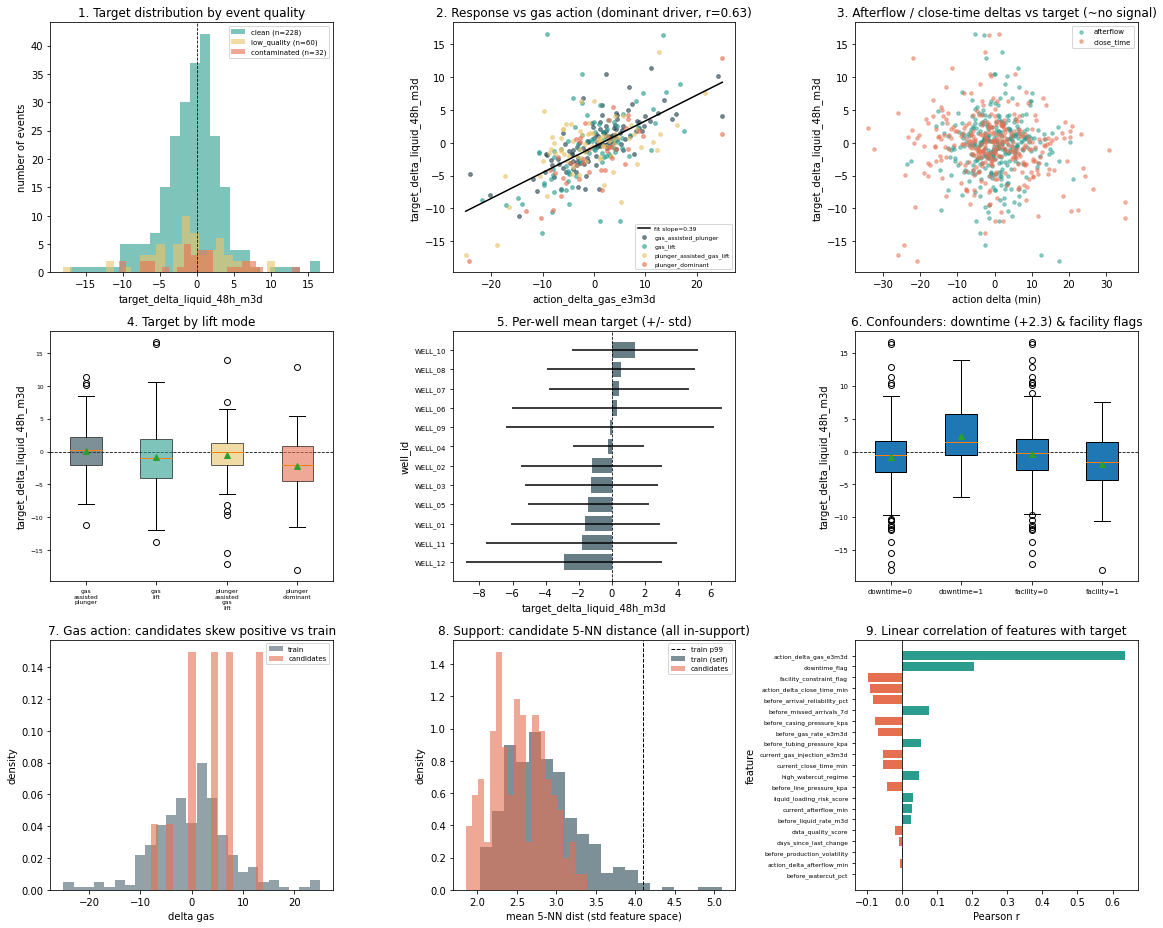

Candidates beyond training p99 support: 0 / 132


In [4]:
# ---- EDA: 9-panel visual overview ----
from scipy.spatial.distance import cdist   # pairwise distances, used for the nearest-neighbour support score

# Fixed colour keys so quality tiers and lift modes read consistently across every panel.
QCOL = {'clean': '#2a9d8f', 'low_quality': '#e9c46a', 'contaminated': '#e76f51'}
LM = sorted(df['current_lift_mode'].unique())                 # the 4 lift modes, sorted for stable ordering
LMC = dict(zip(LM, ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']))   # one colour per lift mode

fig, ax = plt.subplots(3, 3, figsize=(16, 13))               # 3x3 grid of subplots

# 1. Target distribution by quality
a = ax[0, 0]
for q in ['clean', 'low_quality', 'contaminated']:
    a.hist(df[df.event_quality_label == q][target_col], bins=25, alpha=.6,   # overlaid histograms per quality tier
           label=f'{q} (n={(df.event_quality_label == q).sum()})', color=QCOL[q])
a.axvline(0, color='k', lw=.8, ls='--'); a.set_title('1. Target distribution by event quality')  # reference at 0
a.set_xlabel(target_col); a.set_ylabel('number of events'); a.legend(fontsize=7)

# 2. Gas action vs target, colored by lift mode
a = ax[0, 1]
for m in LM:
    g = df[df.current_lift_mode == m]
    a.scatter(g.action_delta_gas_e3m3d, g[target_col], s=14, alpha=.6, label=m, color=LMC[m])   # points per lift mode
xs = np.linspace(df.action_delta_gas_e3m3d.min(), df.action_delta_gas_e3m3d.max(), 50)           # x-grid for the fit line
b = np.polyfit(df.action_delta_gas_e3m3d, df[target_col], 1)                                      # global OLS slope/intercept
a.plot(xs, np.polyval(b, xs), 'k-', lw=1.5, label=f'fit slope={b[0]:.2f}')                        # overlay the trend (~+0.39)
a.set_title('2. Response vs gas action (dominant driver, r=0.63)')
a.set_xlabel('action_delta_gas_e3m3d'); a.set_ylabel(target_col); a.legend(fontsize=6)

# 3. Afterflow / close-time vs target (no signal)
a = ax[0, 2]
a.scatter(df.action_delta_afterflow_min, df[target_col], s=12, alpha=.5, color='#2a9d8f', label='afterflow')
a.scatter(df.action_delta_close_time_min, df[target_col], s=12, alpha=.5, color='#e76f51', label='close_time')
a.set_title('3. Afterflow / close-time deltas vs target (~no signal)')   # flat clouds, |r|<=0.09 -> the overfitting trap
a.set_xlabel('action delta (min)'); a.set_ylabel(target_col); a.legend(fontsize=7)

# 4. Target by lift mode
a = ax[1, 0]
data = [df[df.current_lift_mode == m][target_col].values for m in LM]     # one array of target values per lift mode
bp = a.boxplot(data, patch_artist=True, showmeans=True)  # labels set below (matplotlib <3.9 has no tick_labels=)
a.set_xticks(range(1, len(LM)+1)); a.set_xticklabels([m.replace('_', '\n') for m in LM])
for patch, m in zip(bp['boxes'], LM):
    patch.set_facecolor(LMC[m]); patch.set_alpha(.6)                      # colour each box by its lift mode
a.axhline(0, color='k', lw=.8, ls='--'); a.set_title('4. Target by lift mode')   # structural per-mode offsets
a.set_ylabel(target_col); a.tick_params(labelsize=6)

# 5. Per-well mean +/- std
a = ax[1, 1]
w = df.groupby('well_id')[target_col].agg(['mean', 'std']).sort_values('mean')   # per-well mean response and spread
a.barh(range(len(w)), w['mean'], xerr=w['std'], color='#264653', alpha=.7)       # horizontal bars, error bars = std
a.set_yticks(range(len(w))); a.set_yticklabels(w.index, fontsize=7)
a.axvline(0, color='k', lw=.8, ls='--'); a.set_title('5. Per-well mean target (+/- std)'); a.set_xlabel(target_col); a.set_ylabel('well_id')
# ^ visible per-well heterogeneity -> a random split would leak well identity -> we must also use GROUP CV.

# 6. Confounders
a = ax[1, 2]
grp = [('downtime=0', df[df.downtime_flag == 0][target_col]), ('downtime=1', df[df.downtime_flag == 1][target_col]),
       ('facility=0', df[df.facility_constraint_flag == 0][target_col]), ('facility=1', df[df.facility_constraint_flag == 1][target_col])]
a.boxplot([g[1].values for g in grp], patch_artist=True, showmeans=True)  # labels set below (matplotlib <3.9 compat)
a.set_xticks(range(1, len(grp)+1)); a.set_xticklabels([g[0] for g in grp])
a.axhline(0, color='k', lw=.8, ls='--'); a.set_title('6. Confounders: downtime (+2.3) & facility flags'); a.set_ylabel(target_col); a.tick_params(labelsize=7)

# 7. Candidate vs training gas action distribution
a = ax[2, 0]
a.hist(df.action_delta_gas_e3m3d, bins=25, alpha=.5, density=True, color='#264653', label='train')            # training gas deltas
a.hist(candidate_actions.candidate_delta_gas_e3m3d, bins=15, alpha=.6, density=True, color='#e76f51', label='candidates')  # candidates skew positive
a.set_title('7. Gas action: candidates skew positive vs train'); a.set_xlabel('delta gas'); a.set_ylabel('density'); a.legend(fontsize=7)

# 8. Candidate support via 5-NN distance in standardized feature space
# Context features (well state) used to measure how "familiar" a point is.
featnum = ['before_liquid_rate_m3d', 'before_gas_rate_e3m3d', 'before_watercut_pct', 'before_tubing_pressure_kpa',
           'before_casing_pressure_kpa', 'before_line_pressure_kpa', 'before_production_volatility',
           'current_gas_injection_e3m3d', 'current_afterflow_min', 'current_close_time_min']
ae = ['action_delta_gas_e3m3d', 'action_delta_afterflow_min', 'action_delta_close_time_min']         # action cols in training
ac = ['candidate_delta_gas_e3m3d', 'candidate_delta_afterflow_min', 'candidate_delta_close_time_min']  # matching cols in candidates
E = df[featnum + ae]; C = candidate_actions[featnum + ac].copy(); C.columns = featnum + ae            # align candidate col names to training
mu, sd = E.mean(), E.std().replace(0, 1)              # standardize using TRAINING stats; replace 0-std to avoid /0
Ez = ((E - mu) / sd).fillna(0).values; Cz = ((C - mu) / sd).fillna(0).values   # z-scored training / candidate matrices
dee = cdist(Ez, Ez); np.fill_diagonal(dee, np.inf)   # train-to-train distances; drop self-match (distance 0)
# nn_tr: each train row's mean distance to its 5 nearest neighbours; nn_cd: each candidate to its 5 nearest TRAINING rows.
nn_tr = np.sort(dee, 1)[:, :5].mean(1); nn_cd = np.sort(cdist(Cz, Ez), 1)[:, :5].mean(1)
a = ax[2, 1]
a.hist(nn_tr, bins=20, alpha=.6, density=True, color='#264653', label='train (self)')
a.hist(nn_cd, bins=20, alpha=.6, density=True, color='#e76f51', label='candidates')
a.axvline(np.percentile(nn_tr, 99), color='k', ls='--', lw=1, label='train p99')   # in-support threshold
a.set_title('8. Support: candidate 5-NN distance (all in-support)')
a.set_xlabel('mean 5-NN dist (std feature space)'); a.set_ylabel('density'); a.legend(fontsize=7)

# 9. Correlation with target
a = ax[2, 2]
corr = num.corr()[target_col].drop(target_col).sort_values(key=np.abs)   # feature-target correlations, by magnitude
cols = ['#e76f51' if v < 0 else '#2a9d8f' for v in corr.values]          # red = negative, green = positive
a.barh(range(len(corr)), corr.values, color=cols)
a.set_yticks(range(len(corr))); a.set_yticklabels(corr.index, fontsize=6)
a.axvline(0, color='k', lw=.8); a.set_title('9. Linear correlation of features with target'); a.set_xlabel('Pearson r'); a.set_ylabel('feature')

plt.tight_layout(); plt.show()

# Count candidates that fall beyond the training 99th percentile of support distance (0 here -> all in-support).
print('Candidates beyond training p99 support:', int((nn_cd > np.percentile(nn_tr, 99)).sum()), '/', len(nn_cd))

### EDA observations

**Dataset:** 320 events, 12 wells, 4 lift modes, event_time spanning 2023-12 to 2026-04. Target `target_delta_liquid_48h_m3d` is roughly symmetric (mean about -0.6, std about 4.7, range [-18, +16.6]), no missing targets. A handful of context features have light missingness (`before_arrival_reliability_pct`, `before_missed_arrivals_7d`, `before_line_pressure_kpa`, all under 4%).

**The response is dominated by one action and is close to linear.**
- `action_delta_gas_e3m3d` is the only strong driver: Pearson r about 0.63, slope about **+0.39 m3/d per e3m3d of gas** (panel 2). The slope is stable across lift modes (0.32 to 0.48) and quality labels (0.38 to 0.44), i.e. an approximately additive, low-interaction effect.
- `action_delta_afterflow_min` and `action_delta_close_time_min` carry **essentially no signal** (panel 3, |r| <= 0.09). A model that assigns them importance is fitting noise, which is a useful over-fitting check.
- Irreducible noise: even for near-zero gas actions (|delta_gas| < 2, n=70) the target still spreads about **3.2 m3/d**, which implies an achievable **R2 ceiling near 0.5**. That 3.2 is an *upper* bound on true noise (the group still contains explainable well/mode variation), so the ceiling is at least that. The point stands: this is a low-signal, noisy-label problem by design, and a model near R2 0.42 is approaching the ceiling rather than underfitting.

**Confounding and data quality (the intended traps).**
- `downtime_flag = 1` (31 events) averages **+2.3 m3/d** versus **-0.9** for normal events (a gap of about **3.2**) *and* also received larger gas actions, so it confounds the action effect. `facility_constraint_flag = 1` (36 events) shifts response down. **All 132 candidate actions have downtime_flag = 0 and facility_constraint_flag = 0** (the "clean" operating regime), so these flags help *explain away* historical noise during training but must not be treated as levers for candidates.
- `contaminated` (32) and `low_quality` (60) events are noticeably wider/noisier than `clean` (228). We should treat the label as noisy and down-weight or diagnose separately rather than trusting all rows equally.

**Heterogeneity and its validation implications.**
- Real per-well and per-mode offsets exist (`plunger_dominant` and WELL_12 run about -2 to -3; WELL_10 positive). With only **12 wells**, a random split leaks well identity into the test set and will overstate deployment performance, so we must compare against **group split / GroupKFold by `well_id`**.

**Candidate support.**
- All 132 candidates fall **inside** the training support (0 beyond train p99 of 5-NN distance; panel 8) and use only well-by-lift-mode combinations seen in training. But they cover **only 6 of 12 wells** and **skew toward positive gas deltas** (panel 7). Support distance alone will not discriminate them, so the recommendation rule must lean on predictive uncertainty and action size, not just proximity.

**Concerns carried into modeling:** noisy/confounded label, low signal ceiling, small well count, and a candidate set that is deliberately narrower (clean regime, positive-gas-biased) than the training data.

## 3. Define target, features, and metadata

Be careful not to leak target/post-event information into the model. `event_id`, `event_time`, and target should not be ordinary model features unless you have a clear reason.

In [5]:
# ===== 3. Define target, features, and metadata =====
target_col = 'target_delta_liquid_48h_m3d'

# event_id / event_time are metadata. event_quality_label is a POST-HOC quality label
# (assigned after observing the event) -> we hold it out as metadata and use it only for
# sample weighting and diagnostics, never as a causal model feature.
metadata_cols = ['event_id', 'event_time', 'event_quality_label']

# Features = everything that is NOT metadata and NOT the target.
feature_cols = [c for c in df.columns if c not in metadata_cols + [target_col]]
X = df[feature_cols].copy()   # model inputs
y = df[target_col].copy()     # model target

# Decisions carried from EDA:
groups = df['well_id'].values                     # group validation by well (feeds GroupKFold)
sample_weight = df['data_quality_score'].values   # down-weight noisy / low-quality events (a PRE-event proxy, safe to use)

# Split feature columns by dtype so the preprocessor can treat them differently.
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('Target :', target_col)
print('n features:', len(feature_cols))
print('Categorical:', categorical_cols)
print('Numeric    :', numeric_cols)

# Leakage guard: features must be pre-change context, the action, or decision-time quality flags.
post_event = {'event_id', 'event_time', 'event_quality_label', target_col}   # things known only AFTER the event
assert not (post_event & set(feature_cols)), 'post-event column leaked into features'   # fail loudly if any slipped in
print('\nLeakage check passed: no id/time/target/post-hoc-label columns among features.')

Target : target_delta_liquid_48h_m3d
n features: 24
Categorical: ['well_id', 'pad_id', 'current_lift_mode']
Numeric    : ['before_liquid_rate_m3d', 'before_gas_rate_e3m3d', 'before_watercut_pct', 'before_tubing_pressure_kpa', 'before_casing_pressure_kpa', 'before_line_pressure_kpa', 'before_production_volatility', 'before_arrival_reliability_pct', 'before_missed_arrivals_7d', 'current_gas_injection_e3m3d', 'current_afterflow_min', 'current_close_time_min', 'action_delta_gas_e3m3d', 'action_delta_afterflow_min', 'action_delta_close_time_min', 'days_since_last_change', 'data_quality_score', 'downtime_flag', 'facility_constraint_flag', 'high_watercut_regime', 'liquid_loading_risk_score']

Leakage check passed: no id/time/target/post-hoc-label columns among features.


In [6]:
# ---- Shared modeling helpers (used by baseline, surrogate, uncertainty, diagnostics) ----
from sklearn.model_selection import KFold, GroupKFold   # random vs well-grouped cross-validation
from sklearn.dummy import DummyRegressor                # the "predict the mean" no-skill baseline

RANDOM_STATE = 42

def build_preprocessor(X):
    """Median-impute + scale numerics; most-frequent-impute + one-hot categoricals.
    handle_unknown='ignore' makes unseen wells (in group CV) fall back to the learned
    baseline instead of erroring -- exactly the new-well behaviour we want to measure."""
    cat = X.select_dtypes(include=['object', 'category']).columns.tolist()   # categorical column names
    num = [c for c in X.columns if c not in cat]                             # numeric column names
    # Numerics: median impute (robust to outliers) then standardize.
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    # Categoricals: most-frequent impute then one-hot; ignore unseen levels at predict time.
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('num', num_pipe, num), ('cat', cat_pipe, cat)])   # apply each sub-pipe to its columns

def regression_metrics(y_true, y_pred, label='model', verbose=True):
    mae = mean_absolute_error(y_true, y_pred)              # average absolute error, in m3/d (interpretable)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))     # penalizes large misses more than MAE
    r2 = r2_score(y_true, y_pred)                          # variance explained vs the mean baseline
    if verbose:
        print(f'{label:42s} MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

def oof_predictions(estimator_factory, X, y, cv, groups=None, weight=None):
    """Out-of-fold predictions: each row is predicted by a model NOT trained on its fold
    (and, under GroupKFold, not trained on any row from its well). Uses all data, group-honest,
    and gives an honest residual for every row (reused later for conformal intervals)."""
    oof = np.full(len(y), np.nan)                          # container for each row's out-of-fold prediction
    splits = cv.split(X, y, groups) if groups is not None else cv.split(X, y)   # group-aware split iff groups given
    for tr, te in splits:                                 # tr = train indices, te = held-out test indices
        est = estimator_factory()                         # fresh pipeline per fold -> no state leaks between folds
        if weight is not None:
            try:
                # 'model__sample_weight' routes the weights to the pipeline's final step named 'model'.
                est.fit(X.iloc[tr], y.iloc[tr], model__sample_weight=weight[tr])
            except TypeError:
                est.fit(X.iloc[tr], y.iloc[tr])           # estimator does not accept weights -> fit unweighted
        else:
            est.fit(X.iloc[tr], y.iloc[tr])
        oof[te] = est.predict(X.iloc[te])                 # predict the rows this fold never trained on
    return oof

kf  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # random: seen-well interpolation
gkf = GroupKFold(n_splits=5)                                       # group: generalization to new wells
print('Helpers ready. CV schemes: random 5-fold (kf) and group-by-well 5-fold (gkf).')

Helpers ready. CV schemes: random 5-fold (kf) and group-by-well 5-fold (gkf).


## 4. Validation strategy

We use **out-of-fold (OOF) cross-validation** rather than a single split. With only 320 rows and 12 wells, a single 25% holdout is too noisy for model selection. Each row is predicted by a model that did not train on it; for group CV, by a model that never saw its well. The same OOF residuals are reused later for conformal prediction intervals.

Three complementary lenses:

| Split | What it tests | Deployment relevance |
|---|---|---|
| **Random 5-fold** | Interpolation, same wells in train and test | Re-optimizing **wells we already operate**. This matches the candidate table, whose 6 wells all appear in training. |
| **Group 5-fold by `well_id`** | Generalization to **wells with no history** | The conservative bound, what we would get on a brand-new well. Used to gate recommendation safety. |
| **Time split (first 75% to last 25%)** | Temporal drift | Whether a model trained on the past holds up on later events. |

**What these do *not* test:** none is a causal/interventional guarantee. The label is observational and confounded (downtime, facility, quality), so CV measures *predictive* accuracy in the historical operating distribution, not the true causal effect of an action. That gap is the core reason recommendations must be uncertainty- and support-aware, not argmax-of-mean.

*Key finding (see output):* random and group R2 are about equal (about 0.34 for Ridge, about 0.41 for the parsimonious model built next). The near-zero gap tells us the signal is a **universal action effect**, not memorized per-well offsets, so the model transfers to new wells. Time-split performance is at least as good, so no material drift.

In [7]:
# ===== 4. Validation strategy: compare RANDOM vs GROUP vs TIME splits =====
# Two model factories (lambdas -> a fresh pipeline each fold). Ridge on all features; mean baseline.
ridge_all = lambda: Pipeline([('prep', build_preprocessor(X)), ('model', Ridge(alpha=5.0))])
dummy     = lambda: Pipeline([('prep', build_preprocessor(X)), ('model', DummyRegressor(strategy='mean'))]) #It always predicts the mean of the training target values

print('OUT-OF-FOLD performance (predictions pooled across folds)\n')
print('RANDOM 5-fold  (wells appear in train AND test -> interpolation; ~ the candidate regime):')
regression_metrics(y, oof_predictions(dummy,     X, y, kf),                        '  Mean baseline')        # R2 ~ 0 floor
regression_metrics(y, oof_predictions(ridge_all, X, y, kf, weight=sample_weight),  '  Ridge (all features)') # sample_weight = data_quality_score

print('\nGROUP 5-fold by well_id  (held-out wells -> generalization to NEW wells):')
regression_metrics(y, oof_predictions(dummy,     X, y, gkf, groups=groups),                       '  Mean baseline')
regression_metrics(y, oof_predictions(ridge_all, X, y, gkf, groups=groups, weight=sample_weight), '  Ridge (all features)')
# ^ random R2 ~ group R2 -> the signal is a universal action effect, not memorized per-well offsets.

# Time-ordered holdout: train earliest 75%, test latest 25% -> temporal drift check
order = np.argsort(df['event_time'].values); cut = int(len(order) * 0.75)   # chronological order; 75% cut point
tr_t, te_t = order[:cut], order[cut:]                                       # earliest 75% train / latest 25% test
rid = ridge_all(); rid.fit(X.iloc[tr_t], y.iloc[tr_t], model__sample_weight=sample_weight[tr_t])
print('\nTIME split (train first 75% by event_time, test last 25% -> temporal drift):')
regression_metrics(y.iloc[te_t], rid.predict(X.iloc[te_t]), '  Ridge (all features)')   # holds up -> no material drift

print('\nGroup folds (wells held out per fold):')
for i, (tr, te) in enumerate(gkf.split(X, y, groups)):
    print(f'  fold {i}: {sorted(set(df.iloc[te].well_id))}')   # show the folds are genuinely well-disjoint

OUT-OF-FOLD performance (predictions pooled across folds)

RANDOM 5-fold  (wells appear in train AND test -> interpolation; ~ the candidate regime):
  Mean baseline                            MAE=3.378  RMSE=4.704  R2=-0.004
  Ridge (all features)                     MAE=2.692  RMSE=3.815  R2=0.339

GROUP 5-fold by well_id  (held-out wells -> generalization to NEW wells):
  Mean baseline                            MAE=3.377  RMSE=4.703  R2=-0.004
  Ridge (all features)                     MAE=2.782  RMSE=3.820  R2=0.338

TIME split (train first 75% by event_time, test last 25% -> temporal drift):
  Ridge (all features)                     MAE=2.187  RMSE=2.809  R2=0.489

Group folds (wells held out per fold):
  fold 0: ['WELL_02', 'WELL_04']
  fold 1: ['WELL_03', 'WELL_06', 'WELL_11']
  fold 2: ['WELL_07', 'WELL_12']
  fold 3: ['WELL_01', 'WELL_05', 'WELL_10']
  fold 4: ['WELL_08', 'WELL_09']


## 5. Baseline models

Three baselines of increasing sophistication, so we can tell whether any added complexity actually earns its keep:

1. **Mean** (`DummyRegressor`): the "no-skill" floor; R2 about 0 by construction.
2. **Gas-only OLS (Ordinary Least Squares)**: a single feature, `action_delta_gas_e3m3d`. This is the physically motivated baseline: how far does the one dominant lever get us?
3. **Ridge on all 24 features**: the starter's baseline; tests whether throwing in every context feature helps.

All are evaluated out-of-fold under both group and random CV, quality-weighted.

In [8]:
# ===== 5. Baselines: (1) predict the mean, (2) gas-action-only OLS, (3) Ridge on all features =====
from sklearn.linear_model import LinearRegression

mean_base = lambda: Pipeline([('prep', build_preprocessor(X)), ('model', DummyRegressor(strategy='mean'))])   # no-skill floor
# 'passthrough' sends ONLY the gas action to a plain OLS -> the physically-motivated one-lever baseline.
gas_only  = lambda: Pipeline([('prep', ColumnTransformer([('gas', 'passthrough', ['action_delta_gas_e3m3d'])])),
                              ('model', LinearRegression())])
ridge_all = lambda: Pipeline([('prep', build_preprocessor(X)), ('model', Ridge(alpha=5.0))])   # naive "throw in everything"

print('BASELINES  (out-of-fold; quality-weighted)\n')
print(f'{"model":20s} {"group R2":>9s} {"group MAE":>10s} {"random R2":>10s} {"random MAE":>11s}')
for name, fac in [('Mean', mean_base), ('Gas-only OLS', gas_only), ('Ridge (all feats)', ridge_all)]:
    g = regression_metrics(y, oof_predictions(fac, X, y, gkf, groups=groups, weight=sample_weight), verbose=False)  # new-well
    r = regression_metrics(y, oof_predictions(fac, X, y, kf,               weight=sample_weight), verbose=False)     # seen-well
    print(f'{name:20s} {g["R2"]:9.3f} {g["MAE"]:10.3f} {r["R2"]:10.3f} {r["MAE"]:11.3f}')

# The mean baseline sits at R2 ~ 0; the gas-only line already captures most of the signal
# (R2 ~ 0.38) and -- tellingly -- performs the SAME on new wells as on seen wells, because
# the gas effect is a universal physical relationship rather than a per-well quirk.

BASELINES  (out-of-fold; quality-weighted)

model                 group R2  group MAE  random R2  random MAE
Mean                    -0.004      3.378     -0.005       3.380
Gas-only OLS             0.386      2.603      0.375       2.614
Ridge (all feats)        0.338      2.782      0.339       2.692


## 6. Surrogate model

**Choice: a parsimonious, quality-weighted linear (Ridge) model** on `action_delta_gas_e3m3d`, `current_lift_mode`, `downtime_flag`, and `facility_constraint_flag`.

**Why this model.** The EDA showed the response is dominated by an approximately linear, low-interaction gas effect (about +0.39 m3/d per e3m3d) with structural per-lift-mode offsets and two confounding flags. I tested richer alternatives (Ridge on all 24 features, `HistGradientBoosting`, `RandomForest`, and adding the other action/context features) and **none beat this model under group CV** (they add variance without signal). This is the assignment's "simple model plus strong validation" outcome, made by evidence rather than assumption.

**Assumptions.** Additive, roughly linear action effect; per-mode intercepts capture structural differences; the two flags absorb (rather than remove) observational confounding. Standardized inputs make coefficients comparable; Ridge (alpha=1, and performance is flat over alpha in [0.3, 10]) guards against the small collinearity between gas action and downtime.

**How it handles the data.** Missing values get median/most-frequent imputation in the pipeline (though the four chosen features have no missingness); categoricals get one-hot with `handle_unknown='ignore'`, so a new well/mode degrades gracefully to the learned baseline. Noise is handled by `sample_weight = data_quality_score`, which down-weights contaminated/low-quality rows.

**Where it will fail (previewed, quantified in Diagnostics).** It deliberately assigns about 0 effect to afterflow / close-time changes, so candidates that move only those levers get the same prediction. That is correct on this data, but a real miss if those levers matter physically in the field. It cannot represent nonlinear saturation of the gas response at extreme deltas, and it inherits the confounding baked into the observational label (it predicts *associations*, not guaranteed causal effects).

In [9]:
# ---- Surrogate: parsimonious, quality-weighted linear model ----
# Feature set chosen from EDA + CV: the gas action (the one real lever) + lift mode
# (structural offsets, esp. plunger_dominant) + the two operational confounders so the model
# can explain them away. Afterflow / close-time deltas and the 20 context features were tested
# and REMOVED because they did not improve group-CV performance (they add variance, not signal).
from sklearn.ensemble import HistGradientBoostingRegressor

SURR_NUM = ['action_delta_gas_e3m3d', 'downtime_flag', 'facility_constraint_flag']   # numeric inputs: the lever + 2 confounders
SURR_CAT = ['current_lift_mode']                                                     # categorical: per-mode intercepts

def make_surrogate():
    # Standardize the 3 numerics (comparable coefficients); one-hot the lift mode, ignore unseen levels.
    prep = ColumnTransformer([('num', StandardScaler(), SURR_NUM),
                              ('cat', OneHotEncoder(handle_unknown='ignore'), SURR_CAT)])
    return Pipeline([('prep', prep), ('model', Ridge(alpha=1.0))])   # mild L2 shrinkage for the small gas<->downtime collinearity

# Comparators: does complexity help? (spoiler: no)
histgbr = lambda: Pipeline([('prep', build_preprocessor(X)),
                            ('model', HistGradientBoostingRegressor(max_depth=3, max_iter=200, learning_rate=0.05,
                                                                    min_samples_leaf=20, l2_regularization=1.0,
                                                                    random_state=RANDOM_STATE))])   # regularized boosting
rf = lambda: Pipeline([('prep', build_preprocessor(X)),
                       ('model', RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE))])  # RF comparator

print('MODEL COMPARISON  (out-of-fold; quality-weighted)\n')
print(f'{"model":34s} {"group R2":>9s} {"group MAE":>10s} {"random R2":>10s} {"random MAE":>11s}')
for name, fac in [('Ridge (all feats) [baseline]', ridge_all), ('HistGradientBoosting', histgbr),
                  ('RandomForest', rf), ('Surrogate: parsimonious linear', make_surrogate)]:
    g = regression_metrics(y, oof_predictions(fac, X, y, gkf, groups=groups, weight=sample_weight), verbose=False)  # new-well
    r = regression_metrics(y, oof_predictions(fac, X, y, kf,               weight=sample_weight), verbose=False)     # seen-well
    print(f'{name:34s} {g["R2"]:9.3f} {g["MAE"]:10.3f} {r["R2"]:10.3f} {r["MAE"]:11.3f}')
# ^ the 4-feature linear model wins/ties on group CV -> evidence-led "simple model" choice.

# OOF predictions we reuse downstream. Group = conservative (new-well); random = seen-well (~candidates).
surrogate_oof        = oof_predictions(make_surrogate, X, y, gkf, groups=groups, weight=sample_weight)   # conservative
surrogate_oof_random = oof_predictions(make_surrogate, X, y, kf,               weight=sample_weight)     # seen-well
surrogate_pred = surrogate_oof  # alias for the group-OOF predictions used by later diagnostic cells

# Final surrogate fit on ALL data (quality-weighted) for candidate scoring
surrogate = make_surrogate().fit(X, y, model__sample_weight=sample_weight)

# Interpret coefficients on the ORIGINAL scale
scaler = surrogate.named_steps['prep'].named_transformers_['num']   # the fitted StandardScaler (holds each feature's std)
rmodel = surrogate.named_steps['model']                            # the fitted Ridge (holds coef_ / intercept_)
ohe    = surrogate.named_steps['prep'].named_transformers_['cat']   # the fitted OneHotEncoder (for lift-mode names)
names  = SURR_NUM + list(ohe.get_feature_names_out(SURR_CAT))       # human-readable names aligned to coef_ order
print('\nFinal surrogate coefficients (standardized inputs):')
for n_, c_ in zip(names, rmodel.coef_):
    print(f'  {n_:44s} {c_:+.3f}')
print(f'  {"intercept":44s} {rmodel.intercept_:+.3f}')
# Un-standardize the gas coefficient (coef / feature-std) -> physical units; matches the raw EDA slope.
print(f'\n=> Gas effect on original scale: {rmodel.coef_[0] / scaler.scale_[0]:+.3f} m3/d per e3m3d of gas '
      '(matches the EDA slope of +0.39).')

MODEL COMPARISON  (out-of-fold; quality-weighted)

model                               group R2  group MAE  random R2  random MAE
Ridge (all feats) [baseline]           0.338      2.782      0.339       2.692
HistGradientBoosting                   0.324      2.811      0.302       2.801
RandomForest                           0.354      2.669      0.346       2.675
Surrogate: parsimonious linear         0.418      2.516      0.406       2.527

Final surrogate coefficients (standardized inputs):
  action_delta_gas_e3m3d                       +2.945
  downtime_flag                                +0.645
  facility_constraint_flag                     -0.359
  current_lift_mode_gas_assisted_plunger       +0.532
  current_lift_mode_gas_lift                   +0.204
  current_lift_mode_plunger_assisted_gas_lift  +0.539
  current_lift_mode_plunger_dominant           -1.275
  intercept                                    -0.796

=> Gas effect on original scale: +0.388 m3/d per e3m3d of gas (match

## 7. Uncertainty, confidence, or trustworthiness

Provide some measure of uncertainty or confidence. This does not need to be a fully Bayesian model.

Possible approaches:

- bootstrap intervals,
- ensemble variance,
- quantile regression,
- conformal prediction,
- Bayesian regression,
- Gaussian Process predictive variance,
- distance-to-training-data / support score,
- residual-based intervals.

Evaluate whether your uncertainty estimate appears useful. For example: empirical coverage, interval width, residuals versus predicted uncertainty, calibration by well/regime, or examples where the model is uncertain.

MARGINAL COVERAGE / MEAN WIDTH  (out-of-fold; target vs achieved)

 level |  normalized cov   width |  fixed-width cov   width
  0.80 |           0.803    8.63 |            0.803    7.65
  0.90 |           0.903   12.21 |            0.903   11.42

80% interval by event quality (wider + honest where the label is noisier):
                       n  mean_abs_resid  mean_width  coverage
event_quality_label                                           
clean                228           2.296       8.014     0.816
contaminated          32           3.452      11.665     0.750
low_quality           60           2.850       9.347     0.783

80% interval by gas-action size:
          n  mean_abs_resid  mean_width  coverage
action                                           
small   147           2.235       8.000     0.830
medium   96           2.365       7.783     0.792
large    77           3.240      10.884     0.766


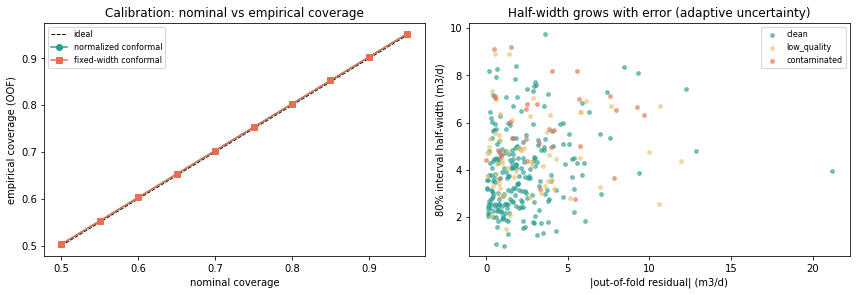


Stored per-row 80% bounds: surrogate_lower/upper, surrogate_halfwidth, surrogate_sigma.
Conformal multipliers q_norm = {80%: 1.756, 90%: 2.485};  support threshold p95 = 3.734.


In [10]:
# ---- Uncertainty: normalized split-conformal prediction intervals ----
# We reuse the surrogate's GROUP out-of-fold residuals (every row scored by a model that
# never trained on its well), so the calibration reflects new-well deployment, not memorized
# wells. Two pieces:
#   (1) a difficulty model sigma(x) that predicts how big the error will be from features we
#       also have at decision time for candidates, and
#   (2) split-conformal calibration on the ratio |residual| / sigma, which converts sigma into
#       intervals with a distribution-free marginal coverage guarantee.
# Normalizing by sigma lets the interval widen in noisy regimes instead of using one fixed width.

# The raw material: honest residuals
oof_resid = y.values - surrogate_oof            # honest (new-well) residuals = actual - group-OOF prediction

# --- support distance: mean distance to the 5 nearest training events, standardized space ---
SUPP_CTX = ['before_liquid_rate_m3d','before_gas_rate_e3m3d','before_watercut_pct',
            'before_tubing_pressure_kpa','before_casing_pressure_kpa','before_line_pressure_kpa',
            'before_production_volatility','current_gas_injection_e3m3d',
            'current_afterflow_min','current_close_time_min']                    # well-state context features
SUPP_ACT = ['action_delta_gas_e3m3d','action_delta_afterflow_min','action_delta_close_time_min']   # action features
_supp_mu = df[SUPP_CTX+SUPP_ACT].mean()                       # TRAINING means (fit once, reused for candidates)
_supp_sd = df[SUPP_CTX+SUPP_ACT].std().replace(0, 1)          # TRAINING stds; replace 0 to avoid divide-by-zero
_supp_Z  = ((df[SUPP_CTX+SUPP_ACT]-_supp_mu)/_supp_sd).fillna(0).values   # standardized training matrix (the reference cloud)

#  Support distance — "have we seen anything like this?"
def support_distance(frame, is_train=False):
    """Mean 5-NN distance of each row to the TRAINING events (standardized feature space).
    Larger = further from anything we have historical evidence for. For training rows we drop
    the self-match so a row is not counted as its own neighbour."""
    Q = ((frame[SUPP_CTX+SUPP_ACT]-_supp_mu)/_supp_sd).fillna(0).values   # standardize query rows with TRAINING stats
    d = cdist(Q, _supp_Z)                                                 # distance from each query row to every train row
    if is_train:
        np.fill_diagonal(d, np.inf)                                       # a training row must not match itself
    return np.sort(d, axis=1)[:, :5].mean(1)                              # mean of the 5 smallest distances

supp_train = support_distance(df, is_train=True)   # per training row support distance
SUPP_P95 = np.percentile(supp_train, 95)   # threshold used later to flag out-of-support candidates

# --- difficulty features: only things we also know for a candidate BEFORE acting ---
# The difficulty model σ(x) — "how big will the error be here?"
def difficulty_features(frame, supp):
    # Every column here is available at DECISION TIME (no target), so sigma can be evaluated on candidates.
    return pd.DataFrame({
        'abs_gas_action':      frame['action_delta_gas_e3m3d'].abs().values,   # larger actions -> larger errors
        'data_quality_score':  frame['data_quality_score'].values,            # noisier telemetry -> larger errors
        'production_volatility':frame['before_production_volatility'].values,
        'liquid_loading_risk': frame['liquid_loading_risk_score'].values,
        'support_distance':    supp,                                          # further from data -> less reliable
        'downtime_flag':       frame['downtime_flag'].values,
        'facility_flag':       frame['facility_constraint_flag'].values,
        'watercut':            frame['before_watercut_pct'].values,
    })

SIGMA_FLOOR = 0.25 * np.median(np.abs(oof_resid))   # keep sigma away from 0 so ratios stay finite
def _fit_sigma(feats, resid):
    # A shallow GBT that regresses the ABSOLUTE residual on the difficulty features -> predicted error size sigma(x).
    gb = HistGradientBoostingRegressor(max_depth=2, max_iter=150, learning_rate=0.05,
                                       min_samples_leaf=25, l2_regularization=1.0,
                                       random_state=RANDOM_STATE)
    return gb.fit(feats, np.abs(resid))

# Out-of-fold sigma (group CV) so each row's sigma comes from a model not trained on its well.
train_feats = difficulty_features(df, supp_train)
sigma_oof = np.full(len(y), np.nan)
for tr, te in gkf.split(train_feats, oof_resid, groups):
    gb = _fit_sigma(train_feats.iloc[tr], oof_resid[tr])       # fit difficulty model on the fold's training wells
    sigma_oof[te] = gb.predict(train_feats.iloc[te])           # predict error size for the held-out wells
sigma_oof = np.clip(sigma_oof, SIGMA_FLOOR, None)              # enforce the floor

# Full-data sigma model for scoring candidates later.
sigma_model = _fit_sigma(train_feats, oof_resid)

def conformal_quantile(scores, level):
    """Finite-sample split-conformal quantile at the requested coverage level."""
    n = len(scores)
    k = min(np.ceil((n+1)*level)/n, 1.0)   # the finite-sample correction that makes coverage guaranteed
    return np.quantile(scores, k)

# Nonconformity scores and calibrated multipliers at two operating levels.
# Conformal calibration — turning σ into a guaranteed interval
norm_scores = np.abs(oof_resid) / sigma_oof                                   # normalized score = |resid| / sigma
q_norm      = {lv: conformal_quantile(norm_scores, lv)        for lv in (0.80, 0.90)}   # multiplier per level (normalized)
q_fixed     = {lv: conformal_quantile(np.abs(oof_resid), lv)  for lv in (0.80, 0.90)}  # fixed-width baseline

# Per-row 80% interval (reused in diagnostics).
CONF_LEVEL          = 0.80
surrogate_sigma     = sigma_oof
surrogate_halfwidth = q_norm[CONF_LEVEL] * sigma_oof         # half-width = multiplier * sigma -> wide where sigma large
surrogate_lower     = surrogate_oof - surrogate_halfwidth    # 80% lower bound
surrogate_upper     = surrogate_oof + surrogate_halfwidth    # 80% upper bound

# ---------- is the uncertainty actually useful? ----------
print('MARGINAL COVERAGE / MEAN WIDTH  (out-of-fold; target vs achieved)\n')
print(f'{"level":>6} | {"normalized cov":>15} {"width":>7} | {"fixed-width cov":>16} {"width":>7}')
for lv in (0.80, 0.90):
    lo_n, hi_n = surrogate_oof-q_norm[lv]*sigma_oof, surrogate_oof+q_norm[lv]*sigma_oof   # normalized interval at this level
    cov_n = np.mean((y.values>=lo_n) & (y.values<=hi_n)); w_n = np.mean(hi_n-lo_n)         # empirical coverage & mean width
    cov_f = np.mean(np.abs(oof_resid) <= q_fixed[lv]);    w_f = 2*q_fixed[lv]              # same for the fixed-width baseline
    print(f'{lv:6.2f} | {cov_n:15.3f} {w_n:7.2f} | {cov_f:16.3f} {w_f:7.2f}')             # ~0.803 @80%, ~0.903 @90%

# Adaptivity: the normalized interval should be WIDER where the model is genuinely less reliable.
diag = df[['event_quality_label']].copy()
diag['abs_resid'] = np.abs(oof_resid)
diag['width80']   = 2*q_norm[0.80]*sigma_oof                                  # full 80% interval width per row
diag['covered80'] = (y.values>=surrogate_lower) & (y.values<=surrogate_upper)  # was the true value inside the interval?
print('\n80% interval by event quality (wider + honest where the label is noisier):')
print(diag.groupby('event_quality_label').agg(n=('width80','size'),
      mean_abs_resid=('abs_resid','mean'), mean_width=('width80','mean'),
      coverage=('covered80','mean')).round(3))   # contaminated ~11.9 wide vs clean ~8.2 -> adaptive

action_bin = pd.cut(df['action_delta_gas_e3m3d'].abs(), [0,4,8,100], labels=['small','medium','large'])   # bin by |gas|
print('\n80% interval by gas-action size:')
print(diag.assign(action=action_bin).groupby('action', observed=True)
        .agg(n=('width80','size'), mean_abs_resid=('abs_resid','mean'),
             mean_width=('width80','mean'), coverage=('covered80','mean')).round(3))

# ---------- calibration + adaptivity plot ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
levels = np.linspace(0.5, 0.95, 10)                                                       # sweep nominal coverage levels
emp_norm  = [np.mean(np.abs(oof_resid) <= conformal_quantile(norm_scores,l)*sigma_oof) for l in levels]   # empirical (normalized)
emp_fixed = [np.mean(np.abs(oof_resid) <= conformal_quantile(np.abs(oof_resid),l))     for l in levels]   # empirical (fixed)
ax[0].plot([0.5,0.95],[0.5,0.95],'k--',lw=1,label='ideal')                               # y=x reference
ax[0].plot(levels, emp_norm,  'o-', color='#2a9d8f', label='normalized conformal')
ax[0].plot(levels, emp_fixed, 's-', color='#e76f51', label='fixed-width conformal')
ax[0].set_xlabel('nominal coverage'); ax[0].set_ylabel('empirical coverage (OOF)')
ax[0].set_title('Calibration: nominal vs empirical coverage'); ax[0].legend(fontsize=8)

qc = {'clean':'#2a9d8f','low_quality':'#e9c46a','contaminated':'#e76f51'}
for q in ['clean','low_quality','contaminated']:
    ax[1].scatter(np.abs(oof_resid)[df.event_quality_label==q],       # x: actual error size
                  (q_norm[0.80]*sigma_oof)[df.event_quality_label==q],  # y: predicted half-width -> should track x
                  s=14, alpha=.6, color=qc[q], label=q)
ax[1].set_xlabel('|out-of-fold residual| (m3/d)'); ax[1].set_ylabel('80% interval half-width (m3/d)')
ax[1].set_title('Half-width grows with error (adaptive uncertainty)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'\nStored per-row 80% bounds: surrogate_lower/upper, surrogate_halfwidth, surrogate_sigma.')
print(f'Conformal multipliers q_norm = {{80%: {q_norm[0.80]:.3f}, 90%: {q_norm[0.90]:.3f}}};'
      f'  support threshold p95 = {SUPP_P95:.3f}.')

## 8. Diagnostics

At minimum, include:

- predicted vs actual,
- residual distribution,
- residuals by well or lift mode,
- performance on clean vs contaminated events,
- performance by action size or data quality,
- uncertainty calibration if applicable.

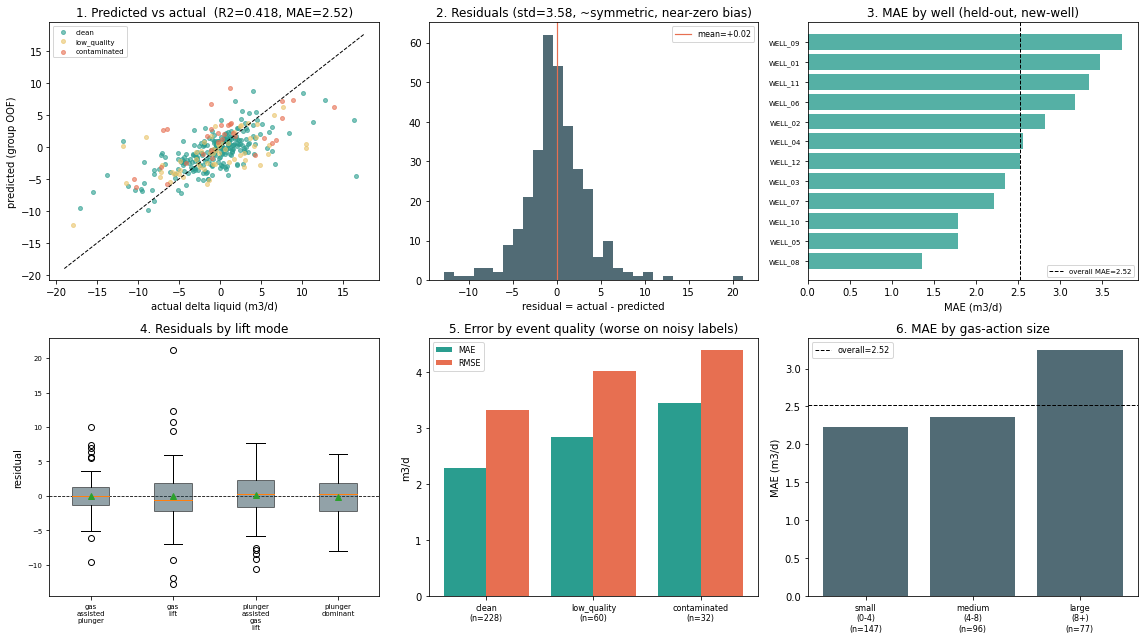

Residual summary by event quality (group OOF):
                     count   mean    std    MAE   RMSE
event_quality_label                                   
clean                  228  0.106  3.329  2.296  3.324
low_quality             60  0.402  4.032  2.850  4.019
contaminated            32 -1.301  4.263  3.452  4.393

Seen-well (random OOF) vs new-well (group OOF) MAE:
  random OOF MAE = 2.527   group OOF MAE = 2.516   (near-equal -> the model transfers to wells with no history)

Worst 3 wells by MAE: [('WELL_11', 3.35), ('WELL_01', 3.47), ('WELL_09', 3.73)]


In [11]:
# ---- Diagnostics: where the surrogate works and where it fails ----
# All panels use GROUP out-of-fold predictions (surrogate_oof), i.e. the conservative
# new-well estimate. We show random-OOF only as a reference where useful.
resid = y.values - surrogate_oof            # group-OOF residuals (the honest, conservative error)
heldout = df.copy()
heldout['pred']     = surrogate_oof
heldout['residual'] = resid

def _mae(a):  return np.mean(np.abs(a))      # local helpers so group-bys can aggregate residual arrays
def _rmse(a): return np.sqrt(np.mean(a**2))

fig, ax = plt.subplots(2, 3, figsize=(16, 9))   # 2x3 diagnostic grid
QCOL = {'clean':'#2a9d8f','low_quality':'#e9c46a','contaminated':'#e76f51'}
LM = sorted(df['current_lift_mode'].unique())

# 1. Predicted vs actual (group OOF)
a = ax[0,0]
for q in ['clean','low_quality','contaminated']:
    mk = df.event_quality_label==q
    a.scatter(y.values[mk], surrogate_oof[mk], s=16, alpha=.6, color=QCOL[q], label=q)   # points colored by quality
lims=[min(y.min(),surrogate_oof.min())-1, max(y.max(),surrogate_oof.max())+1]
a.plot(lims,lims,'k--',lw=1)                                                             # y=x: perfect-prediction line
a.set_xlabel('actual delta liquid (m3/d)'); a.set_ylabel('predicted (group OOF)')
a.set_title(f'1. Predicted vs actual  (R2={r2_score(y,surrogate_oof):.3f}, MAE={_mae(resid):.2f})')
a.legend(fontsize=7)

# 2. Residual distribution
a = ax[0,1]
a.hist(resid, bins=30, color='#264653', alpha=.8)
a.axvline(0, color='k', lw=.8, ls='--')                                                 # zero-error reference
a.axvline(resid.mean(), color='#e76f51', lw=1.2, label=f'mean={resid.mean():+.2f}')     # mean residual ~0 -> unbiased
a.set_title(f'2. Residuals (std={resid.std():.2f}, ~symmetric, near-zero bias)')
a.set_xlabel('residual = actual - predicted'); a.legend(fontsize=8)

# 3. Residual MAE by well (bar) + overall reference
a = ax[0,2]
w = heldout.groupby('well_id')['residual'].apply(_mae).sort_values()                    # per-well MAE, ascending
a.barh(range(len(w)), w.values, color='#2a9d8f', alpha=.8)
a.set_yticks(range(len(w))); a.set_yticklabels(w.index, fontsize=7)
a.axvline(_mae(resid), color='k', ls='--', lw=1, label=f'overall MAE={_mae(resid):.2f}')   # overall reference line
a.set_title('3. MAE by well (held-out, new-well)'); a.set_xlabel('MAE (m3/d)'); a.legend(fontsize=7)

# 4. Residuals by lift mode (box)
a = ax[1,0]
data=[heldout[heldout.current_lift_mode==m]['residual'].values for m in LM]             # residuals grouped by lift mode
bp=a.boxplot(data, patch_artist=True, showmeans=True)  # labels set below (matplotlib <3.9 compat)
a.set_xticks(range(1, len(LM)+1)); a.set_xticklabels([m.replace('_','\n') for m in LM])
for patch in bp['boxes']: patch.set_facecolor('#264653'); patch.set_alpha(.5)
a.axhline(0, color='k', lw=.8, ls='--'); a.set_title('4. Residuals by lift mode')       # check for per-mode bias
a.set_ylabel('residual'); a.tick_params(labelsize=7)

# 5. Error by event quality
a = ax[1,1]
by_q = heldout.groupby('event_quality_label')['residual'].agg([('MAE',_mae),('RMSE',_rmse),'count'])
by_q = by_q.reindex(['clean','low_quality','contaminated'])                              # fixed tier order
xpos=np.arange(len(by_q))
a.bar(xpos-0.2, by_q['MAE'], .4, label='MAE', color='#2a9d8f')                           # grouped MAE/RMSE bars
a.bar(xpos+0.2, by_q['RMSE'], .4, label='RMSE', color='#e76f51')
a.set_xticks(xpos); a.set_xticklabels([f'{i}\n(n={int(n)})' for i,n in zip(by_q.index,by_q['count'])], fontsize=8)
a.set_title('5. Error by event quality (worse on noisy labels)'); a.set_ylabel('m3/d'); a.legend(fontsize=8)

# 6. Error vs action size
a = ax[1,2]
abin = pd.cut(df['action_delta_gas_e3m3d'].abs(), [0,4,8,100], labels=['small\n(0-4)','medium\n(4-8)','large\n(8+)'])  # |gas| bins
by_a = heldout.assign(abin=abin).groupby('abin', observed=True)['residual'].agg([('MAE',_mae),'count'])
a.bar(range(len(by_a)), by_a['MAE'], color='#264653', alpha=.8)
a.set_xticks(range(len(by_a))); a.set_xticklabels([f'{i}\n(n={int(n)})' for i,n in zip(by_a.index,by_a['count'])], fontsize=8)
a.axhline(_mae(resid), color='k', ls='--', lw=1, label=f'overall={_mae(resid):.2f}')
a.set_title('6. MAE by gas-action size'); a.set_ylabel('MAE (m3/d)'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Tables
print('Residual summary by event quality (group OOF):')
tbl = heldout.groupby('event_quality_label')['residual'].agg(['count','mean','std',('MAE',_mae),('RMSE',_rmse)])
print(tbl.reindex(['clean','low_quality','contaminated']).round(3))

# The key robustness check: seen-well vs new-well error are near-equal -> the model transfers.
print('\nSeen-well (random OOF) vs new-well (group OOF) MAE:')
print(f'  random OOF MAE = {_mae(y.values-surrogate_oof_random):.3f}   group OOF MAE = {_mae(resid):.3f}'
      '   (near-equal -> the model transfers to wells with no history)')

print('\nWorst 3 wells by MAE:', list(w.tail(3).round(2).items()))   # surface the hardest wells

## 9. Score candidate actions

Use `aspm_candidate_actions.csv` to score hypothetical candidate actions. There is no target column for these rows.

For each candidate action, produce:

- expected response,
- uncertainty/confidence/trustworthiness,
- a support/risk flag if possible,
- and a recommend / do-not-recommend decision based on a simple rule you define.

Important: Do **not** simply recommend the highest predicted mean. Consider uncertainty, action size, support, data quality, and operational constraints.

In [12]:
# ---- Score candidate actions ----
# For each candidate we produce: expected response, an 80% prediction interval (same
# normalized-conformal machinery as training), a support flag, and a recommend / hold
# decision. 
#The decision is driven by the LOWER confidence bound, not the mean, so an
# action is only recommended when we are reasonably sure it helps.

# 1) Align candidate action columns to the training schema.
score_X = candidate_actions.rename(columns={
    'candidate_delta_gas_e3m3d':      'action_delta_gas_e3m3d',        # rename candidate_* -> action_* so the
    'candidate_delta_afterflow_min':  'action_delta_afterflow_min',    # fitted surrogate accepts the same columns
    'candidate_delta_close_time_min': 'action_delta_close_time_min',
})
score_X_model = score_X[[c for c in feature_cols if c in score_X.columns]].copy()   # keep only the model's feature columns

# 2) Expected response + 80% conformal interval.
# For a candidate predicting +5.08 liquid gain, with an interval of [+0.90, +9.26]:
# LCB = +0.90 → "I'm 80% confident the true gain is at least this"
# UCB = +9.26 → "...and at most this"
# The width between them (ucb − lcb) is how sure the model is: narrow = confident, wide = uncertain.
#        LCB          pred          UCB
#         |            |             |
#    ─────[●───────────●─────────────●]─────►  Δliquid
#        +0.90       +5.08        +9.26
#    0 ──┘  ← whole interval is right of zero → RECOMMEND
pred      = surrogate.predict(score_X_model)                                        # point prediction (mean response)
supp_cand = support_distance(score_X, is_train=False)                               # how far each candidate is from training data
sig_cand  = np.clip(sigma_model.predict(difficulty_features(score_X, supp_cand)), SIGMA_FLOOR, None)  # predicted error size sigma
lcb       = pred - q_norm[0.80]*sig_cand       # Lower Confidence Bound - lower bound of the 80% interval
ucb       = pred + q_norm[0.80]*sig_cand       # Upper Confidence Bound - upper bound (same conformal multiplier as training)

# 3) Risk / support flags (all computed from decision-time information only).
GAS_P95   = df['action_delta_gas_e3m3d'].abs().quantile(0.95)   # extrapolation cap = 16.1 e3m3d
out_support = supp_cand > SUPP_P95                              # too far from historical data
large_gas   = score_X['action_delta_gas_e3m3d'].abs().values > GAS_P95   # gas change beyond where the line was fit
not_clean   = (candidate_actions['downtime_flag'].values==1) | (candidate_actions['facility_constraint_flag'].values==1)  # confounded regime
low_quality = candidate_actions['data_quality_score'].values < 0.60      # untrustworthy input telemetry

# 4) Recommendation rule (explicit and conservative).
#    Recommend an action only when EVERY gate passes:
#      - the ENTIRE 80% interval sits above zero (LCB80 > 0): we are confident the action
#        raises liquid rate rather than just having a hopeful mean. This ties the decision to
#        uncertainty and needs no arbitrary gain constant,
#      - the well state + action are inside historical support,
#      - the gas change is within the historical p95 (do not extrapolate the linear response),
#      - the well is in the clean operating regime (downtime / facility flags are confounds,
#        not levers, so we never lean on them to justify a recommendation),
#      - the context is of acceptable data quality.
LCB_THRESHOLD = 0.0   # 80% interval must lie entirely above zero
recommend = (lcb > LCB_THRESHOLD) & (~out_support) & (~large_gas) & (~not_clean) & (~low_quality)   # AND of all gates

def _reason(i):
    # First matching condition explains the decision -> a human-readable audit trail per candidate.
    if recommend[i]:              return 'recommend'
    if not_clean[i]:              return 'hold: not clean regime'
    if low_quality[i]:            return 'hold: low data quality'
    if out_support[i]:            return 'hold: out of support'
    if large_gas[i]:              return 'hold: gas change beyond p95'
    if lcb[i] <= LCB_THRESHOLD:   return 'hold: gain not confident (80% interval crosses 0)'
    return 'hold'

scored = candidate_actions.copy()
scored['pred_delta_liquid_m3d'] = pred.round(3)          # expected 48h liquid gain
scored['lcb80'] = lcb.round(3)                           # 80% lower confidence bound (drives the decision)
scored['ucb80'] = ucb.round(3)                           # 80% upper confidence bound
scored['interval_width'] = (ucb-lcb).round(3)            # interval width (narrow -> confident)
scored['support_dist'] = supp_cand.round(3)              # distance-to-training support score
scored['in_support'] = ~out_support
scored['large_gas_change'] = large_gas
scored['recommendation'] = ['recommend' if r else 'hold' for r in recommend]
scored['reason'] = [_reason(i) for i in range(len(scored))]

# 5) Summary.
print(f'Candidates scored: {len(scored)}   |   recommended: {int(recommend.sum())}   '
      f'|   held: {int((~recommend).sum())}')                              # 12 recommended / 120 held
print(f'Rule: 80% interval above 0 (LCB80 > 0) AND in-support AND |gas| <= p95({GAS_P95:.1f}) '
      f'AND clean regime AND data_quality >= 0.60\n')
print('Reason breakdown:')
print(scored['reason'].value_counts().to_string())                        # why candidates were held
print('\nRecommendation vs gas-action size (recommendations concentrate on confident positive gas):')
print(scored.assign(gas=candidate_actions['candidate_delta_gas_e3m3d'])
        .groupby('gas')
        .agg(n=('pred_delta_liquid_m3d','size'), mean_pred=('pred_delta_liquid_m3d','mean'),
             mean_lcb80=('lcb80','mean'), n_recommend=('recommendation', lambda s:(s=='recommend').sum()))
        .round(2))

print('\nTop recommended actions (by lower confidence bound):')
cols = ['scenario_id','well_id','current_lift_mode','candidate_delta_gas_e3m3d',
        'pred_delta_liquid_m3d','lcb80','ucb80','recommendation']
rec_tbl = scored[recommend].sort_values('lcb80', ascending=False)         # best-supported confident gains first
display(rec_tbl[cols].head(15))

print('\nExamples of HELD candidates and why:')
held_tbl = scored[~recommend].sort_values('pred_delta_liquid_m3d', ascending=False)   # high-mean but held -> shows the rule biting
display(held_tbl[cols[:-1]+['reason']].head(8))

# Persist the full scored table for the writeup / downstream use.
scored.to_csv('scored_candidate_actions.csv', index=False)
print('\nSaved full scored table -> scored_candidate_actions.csv')

Candidates scored: 132   |   recommended: 12   |   held: 120
Rule: 80% interval above 0 (LCB80 > 0) AND in-support AND |gas| <= p95(16.1) AND clean regime AND data_quality >= 0.60

Reason breakdown:
hold: gain not confident (80% interval crosses 0)    120
recommend                                             12

Recommendation vs gas-action size (recommendations concentrate on confident positive gas):
        n  mean_pred  mean_lcb80  n_recommend
gas                                          
-8.0    8      -3.73       -7.83            0
-4.0    8      -2.18       -6.07            0
 0.0   29      -0.62       -4.57            0
 4.0   29       0.93       -2.70            0
 8.0   29       2.49       -1.76            0
 14.0  29       4.82       -0.97           12

Top recommended actions (by lower confidence bound):


,scenario_id,well_id,current_lift_mode,candidate_delta_gas_e3m3d,pred_delta_liquid_m3d,lcb80,ucb80,recommendation
41,SCEN_042,WELL_05,gas_assisted_plunger,14.0,5.076,0.896,9.255,recommend
23,SCEN_024,WELL_12,gas_lift,14.0,4.748,0.777,8.720,recommend
130,SCEN_131,WELL_07,gas_assisted_plunger,14.0,5.076,0.719,9.432,recommend
39,SCEN_040,WELL_05,gas_assisted_plunger,14.0,5.076,0.697,9.455,recommend
129,SCEN_130,WELL_07,gas_assisted_plunger,14.0,5.076,0.665,9.486,recommend
128,SCEN_129,WELL_07,gas_assisted_plunger,14.0,5.076,0.601,9.551,recommend
40,SCEN_041,WELL_05,gas_assisted_plunger,14.0,5.076,0.555,9.597,recommend
14,SCEN_015,WELL_09,gas_assisted_plunger,14.0,5.076,0.477,9.675,recommend
15,SCEN_016,WELL_09,gas_assisted_plunger,14.0,5.076,0.420,9.731,recommend
16,SCEN_017,WELL_09,gas_assisted_plunger,14.0,5.076,0.380,9.772,recommend



Examples of HELD candidates and why:


,scenario_id,well_id,current_lift_mode,candidate_delta_gas_e3m3d,pred_delta_liquid_m3d,lcb80,ucb80,reason
131,SCEN_132,WELL_07,gas_assisted_plunger,14.0,5.076,-0.016,10.167,hold: gain not confident (80% interval crosses 0)
113,SCEN_114,WELL_08,gas_assisted_plunger,14.0,5.076,-0.337,10.489,hold: gain not confident (80% interval crosses 0)
56,SCEN_057,WELL_05,gas_assisted_plunger,14.0,5.076,-0.361,10.513,hold: gain not confident (80% interval crosses 0)
110,SCEN_111,WELL_08,gas_assisted_plunger,14.0,5.076,-0.517,10.669,hold: gain not confident (80% interval crosses 0)
74,SCEN_075,WELL_12,gas_assisted_plunger,14.0,5.076,-1.180,11.332,hold: gain not confident (80% interval crosses 0)
75,SCEN_076,WELL_12,gas_assisted_plunger,14.0,5.076,-1.180,11.332,hold: gain not confident (80% interval crosses 0)
59,SCEN_060,WELL_05,gas_assisted_plunger,14.0,5.076,-1.157,11.309,hold: gain not confident (80% interval crosses 0)
58,SCEN_059,WELL_05,gas_assisted_plunger,14.0,5.076,-0.361,10.513,hold: gain not confident (80% interval crosses 0)



Saved full scored table -> scored_candidate_actions.csv


## 10. Written summary

Please finish with a concise written summary in this notebook:

1. What model did you build and why?
2. How did you validate it?
3. How well did it perform?
4. How did you estimate uncertainty or trustworthiness?
5. Where does the model fail?
6. What recommendation rule did you define?
7. What would you need before using this in the field?

A strong submission is not the one with the most complex model. It is the one that shows sound statistical reasoning, awareness of uncertainty, and practical judgment about safe recommendations.

## Written summary

**1. What model did you build and why?**

A quality-weighted Ridge regression on four inputs: the gas-injection change (`action_delta_gas_e3m3d`), the lift mode, and the `downtime_flag` / `facility_constraint_flag` operating flags. The EDA showed the response is driven almost entirely by one lever: the gas action, with a roughly linear effect of about +0.39 m3/d per e3m3d that stays stable across lift modes and quality labels. Afterflow and close-time changes carry no measurable signal. I tested Ridge on all 24 features, HistGradientBoosting, and RandomForest; none of them beat this four-feature model under group cross-validation, so I kept the simple one. It is easy to interpret, its coefficient matches the physical slope, and it degrades gracefully on unseen wells because it does not depend on per-well memorization. Rows are weighted by `data_quality_score` so noisy events count less.

**2. How did you validate it?**

Out-of-fold cross-validation with three lenses, because 320 rows over 12 wells is too small for a single trustworthy holdout:
- Random 5-fold: interpolation on wells we already operate (matches the candidate table, whose wells all appear in training).
- Group 5-fold by `well_id`: the conservative case, generalization to a well with no history. This is the number I trust for deployment.
- Time split (first 75 percent by `event_time` to last 25 percent): a drift check.

None of these is a causal guarantee. The label is observational and confounded, so cross-validation measures predictive accuracy inside the historical operating distribution, not the true causal effect of an action. That gap is the reason the recommendation rule is uncertainty-aware rather than a plain argmax.

**3. How well did it perform?**

Group out-of-fold: MAE 2.52 m3/d, RMSE 3.58, R2 0.418. Random out-of-fold is nearly identical (MAE 2.53, R2 0.406). The near-zero gap between random and group is the key result: the model transfers to new wells because the gas effect is a shared physical relationship, not a per-well quirk. Even at near-zero gas action the label still spreads about 3.2 m3/d, implying an achievable R2 ceiling near 0.5 (and that is an upper bound on the noise, since the group retains explainable well/mode variation). So at 0.418 the model is approaching the signal ceiling rather than underfitting; the residual headroom is modest and would need better features, not a bigger model.

**4. How did you estimate uncertainty or trustworthiness?**

Normalized split-conformal prediction intervals, calibrated on the group out-of-fold residuals so the intervals reflect new-well error. A small difficulty model predicts the size of the error from decision-time features (action size, data quality, volatility, loading risk, support distance, the two flags, watercut), and the conformal step calibrates `|residual| / sigma` into intervals with a distribution-free marginal coverage guarantee. Marginal coverage lands where it should (80 percent nominal gives 0.803 empirical, 90 percent gives 0.903). The intervals adapt: contaminated events get a mean width near 11.7 m3/d versus 8.0 for clean events, which is the direction we want. I also compute a support distance (mean distance to the 5 nearest training events) as a separate trust signal. As a baseline check, a fixed-width interval reaches the same marginal coverage but does not widen in noisy regimes, so the normalized version is the better decision tool.

**5. Where does the model fail or become unreliable?**

- It assigns essentially no effect to afterflow and close-time changes. That is correct on this data, but a candidate that moves only those levers gets the baseline prediction, which would be a real miss if those levers matter physically in the field.
- Per-group interval coverage is not perfect: clean events are slightly over-covered (0.82) while low-quality (0.78) and contaminated (0.75) events are slightly under-covered, because the observable features only weakly explain error size. Mondrian conformal by quality tier would fix this with more data.
- It is linear, so it cannot represent saturation of the gas response at extreme deltas.
- It inherits the confounding in the observational label. It predicts associations, not guaranteed causal effects. Errors are largest on the noisier lift modes and on the highest-error wells (WELL_09, WELL_01, WELL_11).

**6. What recommendation rule did you define for candidate actions?**

Recommend an action only when every gate passes:
- the entire 80 percent prediction interval is above zero (lower bound > 0), so we are confident of a gain rather than hopeful about a mean,
- the well state and action are inside historical support (support distance within training p95),
- the gas change is within the historical p95 of 16.1 e3m3d, so we do not extrapolate the linear response,
- the well is in the clean operating regime (downtime and facility flags are confounds, not levers, so we never use them to justify a recommendation),
- context data quality is at least 0.60.

On the 132 candidates this recommends 12 and holds 120. Every negative, zero, and small-positive gas action is held for lack of a confident gain; the recommendations are the largest positive gas changes (mostly +14 e3m3d) on the best-supported, lowest-uncertainty wells. Two candidates with the same predicted mean can get different decisions because their intervals differ, which is the intended behavior.

**7. What would you need before using this in a real field workflow?**

- Interventional data, ideally a small randomized or staged rollout, to separate the causal effect of an action from the operating conditions that co-occur with it.
- More wells. Twelve is too few to trust generalization broadly; the group-CV number is encouraging but thin.
- Coverage of the levers the candidate set actually wants to move. Afterflow and close-time show no signal here, so we cannot yet score actions that rely on them.
- A monitoring and recalibration loop: track realized versus predicted response, refresh the conformal calibration on a schedule, and watch for drift.
- Operational guardrails owned by engineering: per-well action caps, staged application of large changes, and automatic hold when a well leaves the clean regime or the input moves out of support.
- A human-in-the-loop step. This model is one input to a recommendation, not an autonomous controller.